# imprecision-bench: Benchmark Orientation Guide

This notebook introduces the **imprecision-bench** dataset and shows what current language and vision-language models do on it. The benchmark tests a simple pragmatic question: does a model adjust *how precisely* it reports a time depending on social context — saying "8:30" to a police officer but "around half past eight" to a neighbor? Humans do this naturally. Current models largely don't.

**Two tasks:**
- **Task 1 (production):** given a clock image or text description + scenario, complete "It happened ___."  
- **Task 2 (motive elicitation):** given the production + context, explain why that wording was chosen.

**Dataset:** 475 human productions × 12 clock states × 2 contexts (police / neighbor)  
**Source:** Mühlenbernd & Solt (2022), *Linguistics Vanguard*, DOI: 10.1515/lingvan-2022-0035

## 1. Setup

We load the standard data science stack plus the HuggingFace `datasets` library. `MODELS` maps the internal column prefixes used in `results.csv` to display labels; `MODEL_COLORS` keeps the three providers visually consistent across all figures.

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import re
import io
from scipy.stats import wasserstein_distance
from IPython.display import display, Image as IPImage

HF_REPO_ID = "RolandM/imprecision-bench"
RESULTS_CSV = "results.csv"

MODELS = {
    "gpt_4o_mini":             "GPT-4o mini",
    "claude_haiku_4_5":        "Claude Haiku 4.5",
    "google_gemini_2_5_flash": "Gemini 2.5 Flash",
}
MODEL_COLORS = {
    "gpt_4o_mini":             "#74aa9c",
    "claude_haiku_4_5":        "#d97757",
    "google_gemini_2_5_flash": "#4285f4",
}

### API keys

To re-run or extend the evaluation, copy `.env.example` to `.env` and fill in your keys:

```
OPENAI_API_KEY=...       # for gpt-4o, gpt-4o-mini
ANTHROPIC_API_KEY=...    # for claude-* models
OPENROUTER_API_KEY=...   # for google/gemini-* via OpenRouter
TOGETHER_API_KEY=...     # for open-weight models via Together.ai
```

Then run:
```bash
python evaluate.py --model gpt-4o-mini --rows 50   # pilot: first 50 rows
python evaluate.py --model gpt-4o-mini --full       # full: all 475 rows
```

## 2. The Benchmark Data

In [2]:
ds = load_dataset(HF_REPO_ID, split="train")
print(f"Dataset: {len(ds)} rows")

context_names  = ds.features["context"].names
stimulus_names = ds.features["stimulus_type"].names

df_full = ds.to_pandas()
df_full["context_str"]  = df_full["context"].map(lambda x: context_names[x])
df_full["stimulus_str"] = df_full["stimulus_type"].map(lambda x: stimulus_names[x])

print("\nCondition breakdown:")
print(df_full.groupby(["target_time", "context_str"]).size().unstack())

README.md:   0%|          | 0.00/16.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/475 [00:00<?, ? examples/s]

Dataset: 475 rows

Condition breakdown:
context_str  neighbor  police
target_time                  
8:25               19      14
8:26               15      14
8:26-8:34          53      56
8:27               17      16
8:28               22      15
8:29               14      15
8:30               31      30
8:31               18      12
8:32               12      12
8:33               14      17
8:34               17      14
8:35               12      16


Before looking at model outputs, it helps to see what a single benchmark item looks like — the clock image, the full scenario prompt, and a human response. This gives a concrete sense of what both human participants and models are asked to do.

Target time     : 8:30
Context         : police
Stimulus type   : precise
Clock description: Clock description: Hour hand between 8 and 9, halfway. Minute hand at the 6.
Prompt          : One morning when you leave your house, you witness an automobile accident in your street. You look at your watch when it happens. Later that day you are invited to the police station to give a formal witness statement about the accident. The police officer is trying to establish a detailed timeline of the event. He asks you: "What time did the accident happen?" You remember that it happened at the time shown on the clock as given above.

How would you answer in this situation? (Fill the blank)

"It happened ___."
Human production: 8.30 am

Clock image:


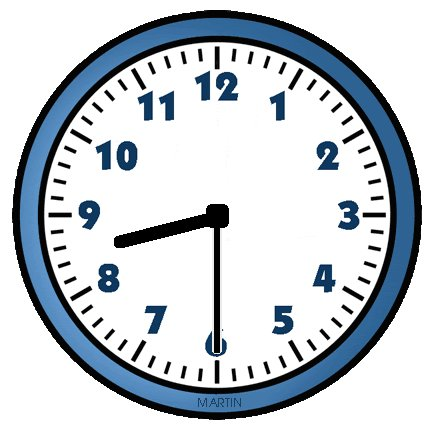

In [3]:
# Show a sample row: clock image, description, and human response
sample_idx = df_full[df_full["context_str"] == "police"].index[0]
sample = df_full.iloc[sample_idx]

print(f"Target time     : {sample['target_time']}")
print(f"Context         : {context_names[sample['context']]}")
print(f"Stimulus type   : {stimulus_names[sample['stimulus_type']]}")
print(f"Clock description: {sample['clock_description']}")
print(f"Prompt          : {sample['prompt']}")
print(f"Human production: {sample['production']}")
print()
print("Clock image:")
img_buf = io.BytesIO()
ds[int(sample_idx)]["clock_image"].save(img_buf, format="PNG")
display(IPImage(data=img_buf.getvalue(), width=200))

## 3. Results Overview

Pre-computed results are stored in `results.csv`. Each model adds three columns:
- `{model}_task1_image` — production from clock *image*
- `{model}_task1_text` — production from clock *text description*
- `{model}_task2` — motive explanation

In [4]:
results = pd.read_csv(RESULTS_CSV)
print(f"Results file: {len(results)} rows, {len(results.columns)} columns")

coverage = {}
for key, label in MODELS.items():
    col = f"{key}_task1_text"
    if col in results.columns:
        coverage[label] = results[col].notna().sum()

print("\nModel coverage (Task 1 text, non-null rows):")
for label, n in coverage.items():
    print(f"  {label}: {n} / {len(results)}")

Results file: 475 rows, 24 columns

Model coverage (Task 1 text, non-null rows):
  GPT-4o mini: 475 / 475
  Claude Haiku 4.5: 475 / 475
  Gemini 2.5 Flash: 475 / 475


## 4. Task 1 — Clock Reading: Image vs. Text

The benchmark includes two versions of Task 1: one where the model sees the **clock image**, and one where it sees a **textual description** of the same clock. This lets us separate visual grounding ability from linguistic pragmatics.

In [5]:
# Show raw outputs side by side for the first 10 rows with data
sample_rows = results.dropna(subset=["gpt_4o_mini_task1_image"]).head(10)

display_cols = ["target_time", "context"]
for key in MODELS:
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    if img_col in results.columns:
        display_cols += [img_col, text_col]

pd.set_option("display.max_colwidth", 35)
display(sample_rows[display_cols].reset_index(drop=True))

,target_time,context,gpt_4o_mini_task1_image,gpt_4o_mini_task1_text,claude_haiku_4_5_task1_image,claude_haiku_4_5_task1_text,google_gemini_2_5_flash_task1_image,google_gemini_2_5_flash_task1_text
0,8:30,police,"""It happened eight o'clock.""","""It happened eight thirty.""",It happened at 8 o'clock,It happened at 8:30,It happened at half past eight,It happened at half past eight
1,8:28,police,"""It happened at eight thirty.""","""It happened eight fifteen.""",It happened at eight o'clock,It happened at approximately 8:15,It happened at half past eight,It happened at twenty-eight min...
2,8:34,police,"""It happened at eight fifteen.""","""It happened eight twenty-four.""",It happened at 8 o'clock,It happened at approximately 8:24,It happened at twenty-five minu...,It happened at twenty-four minu...
3,8:26-8:34,police,"""It happened at 6:40.""","""It happened between 8:25 and 8...",It happened at approximately 9:...,It happened somewhere between 8...,It happened between 8:40 and 9:30,It happened between eight twent...
4,8:30,neighbor,"""It happened at eight o'clock.""","""It happened four thirty.""","""It happened at eight o'clock""",It happened at 8:30,It happened at half past eight,It happened at half past eight
5,8:32,neighbor,"""It happened at eight o'clock.""","""It happened eight twenty-two.""",It happened at eight o'clock,It happened at about 8:12,It happened at twenty-nine minu...,It happened at twenty-two minut...
6,8:26-8:34,neighbor,"""It happened around 6:40.""","""It happened between 8:25 and 8...",It happened at 8 o'clock,It happened between 8:25 and 8:35,It happened between 8:40 and 8:45,It happened sometime between tw...
7,8:30,police,"""It happened eight o'clock.""","""It happened four thirty.""",It happened at 8 o'clock,It happened at 8:30,It happened at half past eight,It happened at half past eight
8,8:34,police,"""It happened at eight fifteen.""","""It happened eight twenty-four.""",It happened at 8 o'clock,It happened at approximately 8:24,It happened at twenty-five minu...,It happened at twenty-four minu...
9,8:26-8:34,police,"""It happened at 6:40.""","""It happened between 8:25 and 8...",It happened at 8 o'clock,It happened somewhere between 8...,It happened between 8:40 and 9:30,It happened between eight twent...


Before applying the full classifier, a quick sanity check: does the response at least mention the right hour? This catches the most common failure mode on the image task — producing a completely wrong time — without needing the full precision classifier.

In [6]:
# Modality gap: heuristic — does the response contain the correct hour digit?
# A rough proxy for clock-reading accuracy on the image task.
def contains_correct_hour(response, target_time):
    """Check if the response mentions the correct hour (8 for all conditions here)."""
    if pd.isna(response):
        return None
    return "8" in str(response) or "eight" in str(response).lower()

pilot = results.dropna(subset=["gpt_4o_mini_task1_image"]).copy()

print("Correct hour mentioned (image task vs text task):")
print(f"{'Model':<35} {'Image':>8} {'Text':>8}")
print("-" * 55)
for key, label in MODELS.items():
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    if img_col not in pilot.columns:
        continue
    img_acc  = pilot[img_col].apply(lambda r: contains_correct_hour(r, None)).mean()
    text_acc = pilot[text_col].apply(lambda r: contains_correct_hour(r, None)).mean()
    print(f"{label:<35} {img_acc:>7.0%} {text_acc:>7.0%}")

Correct hour mentioned (image task vs text task):
Model                                  Image     Text
-------------------------------------------------------
GPT-4o mini                             76%     96%
Claude Haiku 4.5                        81%    100%
Gemini 2.5 Flash                        81%     91%


## 5. Task 1 — Pragmatic Shift: Police vs. Neighbor

The core question: does a model produce *more precise* times for a police officer than for a neighbor? Humans do — they round in casual contexts and give exact times in formal ones.

Measuring pragmatic shift requires a principled classifier. Each response is labelled **precise** (exact target time conveyed), **rounded** (a canonical approximation — 8:25, 8:30, or 8:35), or **other** (wrong time, vague, or non-answer). Two key design decisions: (1) an approximator such as "around" applied to a canonical target counts as *rounded*, not precise — saying "around 8:30" for target 8:30 is a rounding choice; (2) **other** responses are treated as misreadings and excluded from the pragmatic shift denominator, since the interesting question is whether a model that *can* produce a time expression at all adjusts its precision level to context.

In [7]:
# ── Shared helpers (used in Sections 5 and 7) ─────────────────────────────────

MINUTE_WORDS = {
    25: ["twenty-five","twenty five","twenty-five past","twenty five past","25 past","25 minutes past"],
    26: ["twenty-six",  "twenty six"],
    27: ["twenty-seven","twenty seven"],
    28: ["twenty-eight","twenty eight"],
    29: ["twenty-nine", "twenty nine"],
    30: ["thirty", "half"],
    31: ["thirty-one",  "thirty one"],
    32: ["thirty-two",  "thirty two"],
    33: ["thirty-three","thirty three"],
    34: ["thirty-four", "thirty four",
         "twenty-six to nine","twenty six to nine","26 to nine","26 to 9","26 minutes to"],
    35: ["thirty-five", "thirty five",
         "twenty-five to nine","twenty five to nine","25 to nine","25 to 9","25 minutes to"],
}

_APPROX = re.compile(
    r"\baround\b|\babout\b|\broughly\b|\bapproximately\b"
    r"|\bish\b|-ish\b|\bnearly\b|\bjust before\b|\bjust after\b|\bjust past\b"
)
_ROUND = re.compile(
    r"(?<!\d)0?8[:\.]30"
    r"|\bhalf.?past\b|\bhalf\b"
    r"|\bthirty(?!\s*[-–]|\s+(?:one|two|three|four|five|six|seven|eight|nine)\b)\b"
    r"|(?<!\d)0?8[:\.]25"
    r"|\btwenty.?five\b|\b25\s*(?:minutes?\s*)?past\b"
    r"|(?<!\d)0?8[:\.]35"
    r"|\bthirty.?five\b"
    r"|\bto\s*(?:nine|9)\b"
)
_CANONICAL = {"8:25", "8:30", "8:35"}

def time_correct(response, target_time):
    """True if the response conveys the exact target time (digit or word form)."""
    if pd.isna(response):
        return None
    r = str(response).lower()
    has_hour = ("8" in r or "eight" in r
                or bool(re.search(r"\bto\s*(?:nine|9)\b", r)))
    if not has_hour:
        return False
    if "-" in str(target_time):
        off = [26, 27, 28, 29, 31, 32, 33, 34]
        return (any(str(m) in r for m in off)
                or any(w in r for m in off for w in MINUTE_WORDS.get(m, [])))
    minute = int(str(target_time).split(":")[1])
    return str(minute) in r or any(w in r for w in MINUTE_WORDS.get(minute, []))

def classify(response, target_time):
    """Three-way precision classification.

    precise : exact target time conveyed; or exact time + approximator for non-canonical targets
    rounded : canonical round time (8:25/8:30/8:35) but not the exact target
    other   : wrong time, vague, or non-answer
    """
    if pd.isna(response):
        return "other"
    r = str(response).lower()
    has_approx = bool(_APPROX.search(r))
    if time_correct(response, target_time):
        # "around 8:30" for target 8:30 → rounded (approximator on canonical time)
        if has_approx and str(target_time) in _CANONICAL:
            return "rounded"
        return "precise"
    has_eight = "8" in r or "eight" in r
    to_nine   = bool(re.search(r"\bto\s*(?:nine|9)\b", r))
    if (has_eight or to_nine) and _ROUND.search(r):
        return "rounded"
    return "other"

A preview of the pragmatic shift on the full dataset. Both the marginal precise rate and the conditional rate — precise ÷ (precise + rounded), excluding misreadings — are shown. The conditional rate is the cleaner signal for pragmatic calibration because it asks: given that the model produced a valid time expression, did it choose the right level of precision?

In [8]:
# Pragmatic shift preview — does the model give more precise answers for police?
# Each response: precise / rounded / other.
# Conditional rate = precise / (precise + rounded), excluding "other" misreadings.

pilot = results.dropna(subset=["gpt_4o_mini_task1_text"]).copy()

print("Precise response rate by context (text task) — marginal and conditional:")
print(f"{'Model':<35} {'Police':>8} {'Neighbor':>8} {'Shift':>7}  {'Cond-P':>7} {'Cond-N':>7} {'ΔCond':>7}")
print("-" * 90)
for key, label in MODELS.items():
    col = f"{key}_task1_text"
    if col not in pilot.columns:
        continue
    pilot["cls"] = pilot.apply(lambda r: classify(r[col], r["target_time"]), axis=1)
    p_grp = pilot[pilot["context"] == "police"]["cls"]
    n_grp = pilot[pilot["context"] == "neighbor"]["cls"]
    p_prec = (p_grp == "precise").mean()
    n_prec = (n_grp == "precise").mean()
    # conditional: exclude "other"
    p_cond = (p_grp == "precise").sum() / (p_grp.isin(["precise","rounded"])).sum()
    n_cond = (n_grp == "precise").sum() / (n_grp.isin(["precise","rounded"])).sum()
    print(f"{label:<35} {p_prec:>7.1%} {n_prec:>7.1%} {p_prec-n_prec:>+6.1%}  {p_cond:>6.1%} {n_cond:>6.1%} {p_cond-n_cond:>+6.1%}")

# Human baseline
df_full["cls"] = df_full.apply(lambda r: classify(r["production"], r["target_time"]), axis=1)
h_police   = df_full[df_full["context_str"] == "police"]["cls"]
h_neighbor = df_full[df_full["context_str"] == "neighbor"]["cls"]
hp = (h_police == "precise").mean(); hn = (h_neighbor == "precise").mean()
hp_c = (h_police=="precise").sum()/(h_police.isin(["precise","rounded"])).sum()
hn_c = (h_neighbor=="precise").sum()/(h_neighbor.isin(["precise","rounded"])).sum()
print(f"{'Human baseline':<35} {hp:>7.1%} {hn:>7.1%} {hp-hn:>+6.1%}  {hp_c:>6.1%} {hn_c:>6.1%} {hp_c-hn_c:>+6.1%}")
print("\nHumans are more precise in the police context. Do models replicate this? (See Section 7.)")

Precise response rate by context (text task) — marginal and conditional:
Model                                 Police Neighbor   Shift   Cond-P  Cond-N   ΔCond
------------------------------------------------------------------------------------------


GPT-4o mini                           32.5%   38.9%  -6.5%   56.8%  62.1%  -5.3%
Claude Haiku 4.5                      31.2%   37.7%  -6.5%   51.1%  61.7% -10.7%
Gemini 2.5 Flash                      55.0%   53.7%  +1.3%   75.1%  70.4%  +4.7%
Human baseline                        62.3%   53.3%  +9.1%   65.5%  55.6%  +9.9%

Humans are more precise in the police context. Do models replicate this? (See Section 7.)


## 6. Task 2 — Motive Elicitation (Sample)

Task 2 asks the model to explain *why* a given time expression was chosen. This is not yet scored quantitatively — it is an open contribution opportunity.

In [9]:
# Show three Task 2 examples for each model
sample = results.dropna(subset=["gpt_4o_mini_task2"]).head(3)
for _, row in sample.iterrows():
    print(f"[{row['context']} | {row['target_time']}]")
    print(f"  Human:   {row['human_production']}")
    for key, label in MODELS.items():
        col = f"{key}_task2"
        if col in row and pd.notna(row[col]):
            print(f"  {label[:25]}: {str(row[col])[:120]}")
    print()

[police | 8:30]
  Human:   8.30 am
  GPT-4o mini: I chose to answer "It happened 8.30 am" to provide a clear and direct response that includes both the time and the conte
  Claude Haiku 4.5: # Language Choice Analysis

I chose to answer "It happened 8.30 am" rather than alternatives like "8:30 am" or "half pas
  Gemini 2.5 Flash: I chose "8:30 am" to provide a precise and unambiguous time. The "am" clarifies that it occurred in the morning, prevent

[police | 8:28]
  Human:   around half 8
  GPT-4o mini: I chose to answer "It happened around half 8" to provide a more general estimate that might be easier for the officer to
  Claude Haiku 4.5: You chose to use the colloquial phrase "around half 8" rather than the precise time "8:28" because it more accurately re
  Gemini 2.5 Flash: I chose to answer "It happened around half 8" because it's a common, colloquial way to express a time close to 8:30. Whi

[police | 8:34]
  Human:   Just before twenty five to nine
  GPT-4o mini: I chose to a

## 7. Full Analysis (475 rows)

The following cells use the complete 475-row dataset to quantify the two headline findings: the **modality gap** and the **pragmatic shift failure**.

The first question is basic: how often does a model even convey the correct target time? A model that cannot reliably read a clock cannot be expected to show pragmatic sensitivity. We compute this accuracy separately for the image and text versions of Task 1, treating both modalities as equal citizens. Range-stimulus rows (8:26–8:34) are included; the classifier requires at least one off-round minute to appear in the response.

In [10]:
# ── Clock-reading accuracy (full 475 rows) ────────────────────────────────────
# time_correct() and classify_production() are defined in Section 5.
# Here: what fraction of responses convey the correct target time?
# Range-stimulus rows (8:26-8:34) are included; time_correct() handles them.

acc_rows = []
for key, label in MODELS.items():
    img_col  = f"{key}_task1_image"
    text_col = f"{key}_task1_text"
    df = results.dropna(subset=[img_col, text_col]).copy()
    img_acc  = df.apply(lambda r: time_correct(r[img_col],  r["target_time"]), axis=1).mean()
    text_acc = df.apply(lambda r: time_correct(r[text_col], r["target_time"]), axis=1).mean()
    acc_rows.append({"model": label, "key": key, "image": img_acc, "text": text_acc, "n": len(df)})

acc_df = pd.DataFrame(acc_rows)
print("Clock-reading accuracy (% of responses conveying the correct time):")
print(f"{'Model':<25} {'N':>5} {'Image':>8} {'Text':>8} {'Gap':>8}")
print("-" * 60)
for _, row in acc_df.iterrows():
    print(f"{row['model']:<25} {int(row['n']):>5} {row['image']:>7.1%} {row['text']:>7.1%} {row['text']-row['image']:>+7.1%}")

Clock-reading accuracy (% of responses conveying the correct time):
Model                         N    Image     Text      Gap
------------------------------------------------------------
GPT-4o mini                 475    2.7%   35.8%  +33.1%
Claude Haiku 4.5            475    0.2%   38.1%  +37.9%
Gemini 2.5 Flash            475   26.9%   54.3%  +27.4%


Figure 1 visualises the modality gap across the three models. The dramatic difference between image and text accuracy sets the context for the pragmatic shift analysis: any model that cannot reliably read a clock is fundamentally limited as a pragmatic observer.

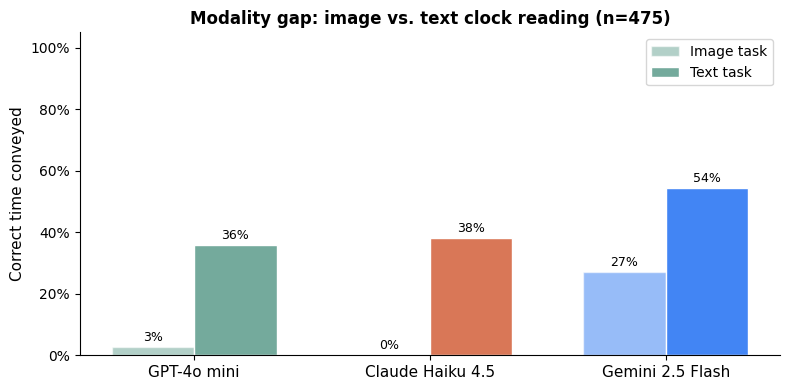

In [11]:
# ── Figure 1: Modality gap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

x      = np.arange(len(acc_df))
width  = 0.35
labels = acc_df["model"].tolist()
colors = [MODEL_COLORS[k] for k in acc_df["key"]]

bars_img  = ax.bar(x - width/2, acc_df["image"],  width, label="Image task",  color=colors, alpha=0.55, edgecolor="white")
bars_text = ax.bar(x + width/2, acc_df["text"],   width, label="Text task",   color=colors, alpha=1.00, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Correct time conveyed", fontsize=11)
ax.set_title("Modality gap: image vs. text clock reading (n=475)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars
for bar in list(bars_img) + list(bars_text):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.0%}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("modality_gap.png", dpi=150, bbox_inches="tight")
plt.show()

Now the core question: does context affect precision? We classify every response and compute the precise rate separately for police and neighbor contexts, along with the marginal shift (Δ precise) and conditional shift (Δ precise ÷ (precise + rounded)). The Wasserstein distance summarises how different the overall response distributions are between the two contexts.

In [12]:
# ── Pragmatic shift: full dataset (3-way classification) ──────────────────────
# Each response: precise / rounded / other.
# Marginal shift = Δ precise rate (police − neighbor).
# Conditional shift = Δ (precise / (precise+rounded)), excluding misreadings.

from scipy.stats import mannwhitneyu

CATS = ["precise", "rounded", "other"]
CODE = {"precise": 0, "rounded": 1, "other": 2}

shift_rows = []

for key, label in MODELS.items():
    col = f"{key}_task1_text"
    df = results.dropna(subset=[col]).copy()
    df["cls"] = df.apply(lambda r: classify(r[col], r["target_time"]), axis=1)
    p = df[df["context"] == "police"]["cls"].value_counts(normalize=True)
    n = df[df["context"] == "neighbor"]["cls"].value_counts(normalize=True)
    wd = wasserstein_distance(
        df[df["context"] == "police"]["cls"].map(CODE).values,
        df[df["context"] == "neighbor"]["cls"].map(CODE).values,
    )
    pp, pr = p.get("precise", 0), p.get("rounded", 0)
    np_, nr = n.get("precise", 0), n.get("rounded", 0)
    p_cond = pp / (pp + pr) if (pp + pr) > 0 else 0
    n_cond = np_ / (np_ + nr) if (np_ + nr) > 0 else 0
    shift_rows.append({"source": label, "key": key,
                       **{f"p_{c}": p.get(c, 0) for c in CATS},
                       **{f"n_{c}": n.get(c, 0) for c in CATS},
                       "p_cond": p_cond, "n_cond": n_cond, "wd": wd})

# Human baseline
df_full["cls"] = df_full.apply(lambda r: classify(r["production"], r["target_time"]), axis=1)
hp = df_full[df_full["context_str"] == "police"]["cls"].value_counts(normalize=True)
hn = df_full[df_full["context_str"] == "neighbor"]["cls"].value_counts(normalize=True)
human_wd = wasserstein_distance(
    df_full[df_full["context_str"] == "police"]["cls"].map(CODE).values,
    df_full[df_full["context_str"] == "neighbor"]["cls"].map(CODE).values,
)
hpp, hpr = hp.get("precise", 0), hp.get("rounded", 0)
hnp, hnr = hn.get("precise", 0), hn.get("rounded", 0)
hp_cond = hpp / (hpp + hpr) if (hpp + hpr) > 0 else 0
hn_cond = hnp / (hnp + hnr) if (hnp + hnr) > 0 else 0
shift_rows.append({"source": "Human baseline", "key": "human",
                   **{f"p_{c}": hp.get(c, 0) for c in CATS},
                   **{f"n_{c}": hn.get(c, 0) for c in CATS},
                   "p_cond": hp_cond, "n_cond": hn_cond, "wd": human_wd})

shift_df = pd.DataFrame(shift_rows)

print("Pragmatic shift — text task, full dataset (precise / rounded / other):")
print(f"\n{'Source':<22}  {'Police':^27}  {'Neighbor':^27}  {'Δmarg':>6} {'Δcond':>6} {'WD':>7}")
print(f"{'':22}  {'prec':>8} {'rnd':>8} {'oth':>8}  {'prec':>8} {'rnd':>8} {'oth':>8}")
print("-" * 104)
for _, r in shift_df.iterrows():
    delta_m = r["p_precise"] - r["n_precise"]
    delta_c = r["p_cond"]   - r["n_cond"]
    print(f"{r['source']:<22}  {r['p_precise']:>7.1%} {r['p_rounded']:>8.1%} {r['p_other']:>8.1%}"
          f"  {r['n_precise']:>7.1%} {r['n_rounded']:>8.1%} {r['n_other']:>8.1%}"
          f"  {delta_m:>+5.1%} {delta_c:>+5.1%} {r['wd']:>7.4f}")

Pragmatic shift — text task, full dataset (precise / rounded / other):

Source                            Police                      Neighbor             Δmarg  Δcond      WD
                            prec      rnd      oth      prec      rnd      oth
--------------------------------------------------------------------------------------------------------
GPT-4o mini               32.5%    24.7%    42.9%    38.9%    23.8%    37.3%  -6.5% -5.3%  0.1203
Claude Haiku 4.5          31.2%    29.9%    39.0%    37.7%    23.4%    38.9%  -6.5% -10.7%  0.0656
Gemini 2.5 Flash          55.0%    18.2%    26.8%    53.7%    22.5%    23.8%  +1.3% +4.7%  0.0436
Human baseline            62.3%    32.9%     4.8%    53.3%    42.6%     4.1%  +9.1% +9.9%  0.0972


Figure 2 plots the shift data visually. The left panel shows the raw precise rate for each context; the right panel isolates the direction and magnitude of the shift. A bar above the dashed zero line means the model — like humans — is more precise in the police context.

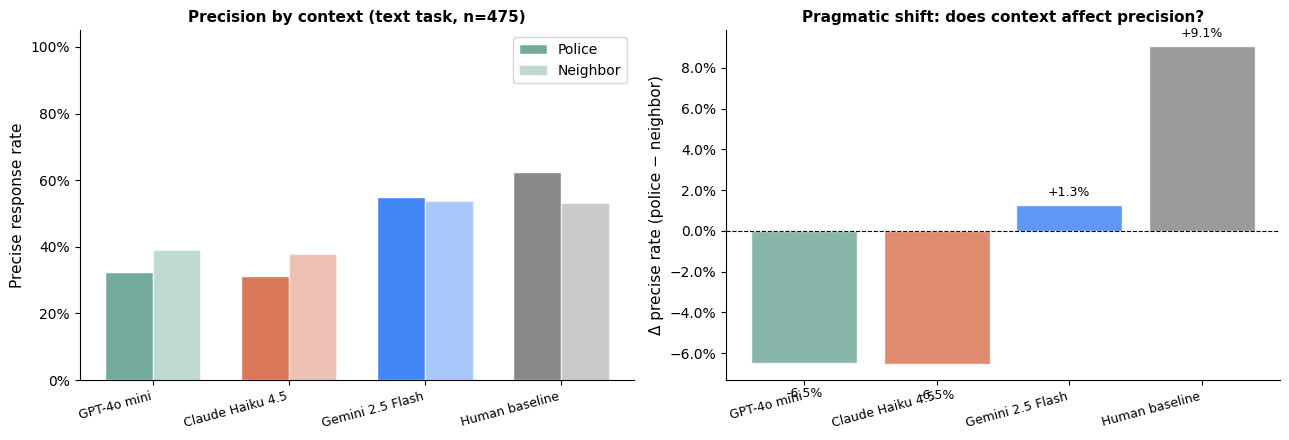

In [13]:
# ── Figure 2: Pragmatic shift ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sources = shift_df["source"].tolist()
x       = np.arange(len(sources))
w       = 0.35
bar_colors = [MODEL_COLORS.get(r["key"], "#888888") for _, r in shift_df.iterrows()]

# Left: precise rate police vs neighbor
ax = axes[0]
ax.bar(x - w/2, shift_df["p_precise"], w, label="Police",   color=bar_colors, alpha=1.0,  edgecolor="white")
ax.bar(x + w/2, shift_df["n_precise"], w, label="Neighbor", color=bar_colors, alpha=0.45, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Precise response rate", fontsize=11)
ax.set_title("Precision by context (text task, n=475)", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Right: Δ precise (police − neighbor)
ax = axes[1]
deltas = shift_df["p_precise"] - shift_df["n_precise"]
bars   = ax.bar(x, deltas, color=bar_colors, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Δ precise rate (police − neighbor)", fontsize=11)
ax.set_title("Pragmatic shift: does context affect precision?", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.003 if val >= 0 else -0.012),
            f"{val:+.1%}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("pragmatic_shift.png", dpi=150, bbox_inches="tight")
plt.show()

The Wasserstein distance (WD) over the 3-way coding (0 = precise, 1 = rounded, 2 = other) captures the total distributional difference between police and neighbor responses in a single number. Expressed as a percentage of the human baseline, it serves as a context-sensitivity calibration score: how much of the human pragmatic effect does this model replicate?

In [14]:
# ── Wasserstein distance against human baseline ───────────────────────────────
# Productions are coded 0=precise, 1=rounded, 2=other for both models and humans.
# WD measures how much the distribution shifts between police and neighbor contexts.
# Human WD sets the gold-standard target; models should approach it.

print("Wasserstein distance (3-way coding: 0=precise, 1=rounded, 2=other)")
print(f"Measures context-sensitivity; human baseline = {human_wd:.4f}\n")
print(f"{'Source':<22} {'WD':>8}  {'% of human':>12}")
print("-" * 46)
print(f"{'Human baseline':<22} {human_wd:>8.4f}  {'(reference)':>12}")
for _, r in shift_df[shift_df["key"] != "human"].iterrows():
    pct = r["wd"] / human_wd * 100
    print(f"{r['source']:<22} {r['wd']:>8.4f}  {pct:>10.1f}%")

Wasserstein distance (3-way coding: 0=precise, 1=rounded, 2=other)
Measures context-sensitivity; human baseline = 0.0972

Source                       WD    % of human
----------------------------------------------
Human baseline           0.0972   (reference)
GPT-4o mini              0.1203       123.7%
Claude Haiku 4.5         0.0656        67.5%
Gemini 2.5 Flash         0.0436        44.8%


### Zooming in: off-round targets only

The analysis above includes the three canonical clock states — 8:25, 8:30, and 8:35. For these targets, stating the time precisely *and* rounding to the canonical value produce the same output, so it is impossible to tell whether a model is being precise or merely rounding. Only the eight **off-round** states (8:26–8:29, 8:31–8:34) allow an unambiguous test: if a model says "8:30" for target 8:28, that is clearly rounding; if it says "8:28", that is precision. This is the subset used by Mühlenbernd & Solt (2022) as their primary evidence for pragmatic context effects in human production, and it is the strictest test of whether models show the same behaviour.

In [15]:
# ── Off-round subset: rounding vs. precision on unambiguous targets ────────────
# Canonical targets (8:25 / 8:30 / 8:35) make it impossible to distinguish
# genuine rounding from simply stating the target. Only the eight off-round
# states (8:26–8:29, 8:31–8:34) allow an unambiguous test of rounding behaviour.
# This replicates the methodology of Mühlenbernd & Solt (2022).

OFF_ROUND = {"8:26", "8:27", "8:28", "8:29", "8:31", "8:32", "8:33", "8:34"}

or_rows = []

for key, label in MODELS.items():
    col = f"{key}_task1_text"
    df  = results[results["target_time"].isin(OFF_ROUND)].dropna(subset=[col]).copy()
    df["cls"] = df.apply(lambda r: classify(r[col], r["target_time"]), axis=1)
    p_grp = df[df["context"] == "police"]["cls"]
    n_grp = df[df["context"] == "neighbor"]["cls"]
    pp, pr = (p_grp=="precise").mean(), (p_grp=="rounded").mean()
    np_, nr = (n_grp=="precise").mean(), (n_grp=="rounded").mean()
    p_cond = pp/(pp+pr) if (pp+pr)>0 else 0
    n_cond = np_/(np_+nr) if (np_+nr)>0 else 0
    wd = wasserstein_distance(
        p_grp.map(CODE).values, n_grp.map(CODE).values
    )
    stat, pval = mannwhitneyu(
        (n_grp=="rounded").astype(int), (p_grp=="rounded").astype(int), alternative="greater"
    )
    or_rows.append({"source": label, "key": key,
                    "p_prec": pp, "p_rnd": pr, "n_prec": np_, "n_rnd": nr,
                    "p_cond": p_cond, "n_cond": n_cond, "delta_cond": p_cond-n_cond,
                    "wd": wd, "pval": pval,
                    "n_police": len(p_grp), "n_neighbor": len(n_grp)})

# Human
df_hor = df_full[df_full["target_time"].isin(OFF_ROUND)].copy()
df_hor["cls"] = df_hor.apply(lambda r: classify(r["production"], r["target_time"]), axis=1)
hp_g = df_hor[df_hor["context_str"]=="police"]["cls"]
hn_g = df_hor[df_hor["context_str"]=="neighbor"]["cls"]
hpp, hpr = (hp_g=="precise").mean(), (hp_g=="rounded").mean()
hnp, hnr = (hn_g=="precise").mean(), (hn_g=="rounded").mean()
hp_c = hpp/(hpp+hpr) if (hpp+hpr)>0 else 0
hn_c = hnp/(hnp+hnr) if (hnp+hnr)>0 else 0
h_wd = wasserstein_distance(hp_g.map(CODE).values, hn_g.map(CODE).values)
stat, hpval = mannwhitneyu(
    (hn_g=="rounded").astype(int), (hp_g=="rounded").astype(int), alternative="greater"
)
or_rows.append({"source": "Human baseline", "key": "human",
                "p_prec": hpp, "p_rnd": hpr, "n_prec": hnp, "n_rnd": hnr,
                "p_cond": hp_c, "n_cond": hn_c, "delta_cond": hp_c-hn_c,
                "wd": h_wd, "pval": hpval,
                "n_police": len(hp_g), "n_neighbor": len(hn_g)})

or_df = pd.DataFrame(or_rows)

print(f"Off-round subset (targets: {', '.join(sorted(OFF_ROUND))}, text task)")
print(f"n per source: police={or_df.iloc[0]['n_police']}, neighbor={or_df.iloc[0]['n_neighbor']}\n")
print(f"{'Source':<22} {'P-prec':>7} {'P-rnd':>7} {'N-prec':>7} {'N-rnd':>7}"
      f" {'Δcond':>6} {'WD':>7} {'p-val':>7}")
print("-" * 78)
for _, r in or_df.iterrows():
    sig = "***" if r["pval"]<0.001 else ("** " if r["pval"]<0.01 else ("*  " if r["pval"]<0.05 else "   "))
    print(f"{r['source']:<22} {r['p_prec']:>6.1%} {r['p_rnd']:>7.1%}"
          f" {r['n_prec']:>6.1%} {r['n_rnd']:>7.1%}"
          f" {r['delta_cond']:>+5.1%} {r['wd']:>7.4f} {r['pval']:>6.4f} {sig}")
print("\nΔcond = conditional-precise shift (police − neighbor), excluding 'other'.")
print("p-val = one-tailed Mann-Whitney U (H₁: neighbor rounds more than police).")
print("*** p<0.001  ** p<0.01  * p<0.05")

Off-round subset (targets: 8:26, 8:27, 8:28, 8:29, 8:31, 8:32, 8:33, 8:34, text task)
n per source: police=115, neighbor=129

Source                  P-prec   P-rnd  N-prec   N-rnd  Δcond      WD   p-val
------------------------------------------------------------------------------
GPT-4o mini             24.3%    0.9%  30.2%    4.7% +9.9%  0.1555 0.0392 *  
Claude Haiku 4.5        21.7%    0.0%  26.4%    0.0% +0.0%  0.0923 1.0000    
Gemini 2.5 Flash        51.3%    0.0%  50.4%    8.5% +14.5%  0.0853 0.0007 ***
Human baseline          70.4%   23.5%  51.2%   43.4% +20.9%  0.1993 0.0005 ***

Δcond = conditional-precise shift (police − neighbor), excluding 'other'.
p-val = one-tailed Mann-Whitney U (H₁: neighbor rounds more than police).
*** p<0.001  ** p<0.01  * p<0.05


Figure 3 plots the rounding rate for police and neighbor contexts on the off-round subset. A higher neighbor bar — neighbor rounds more than police — replicates the human pragmatic effect. The flat zero bars for Claude Haiku explain why no shift is detectable for that model: it simply never rounds on off-round targets, regardless of context.

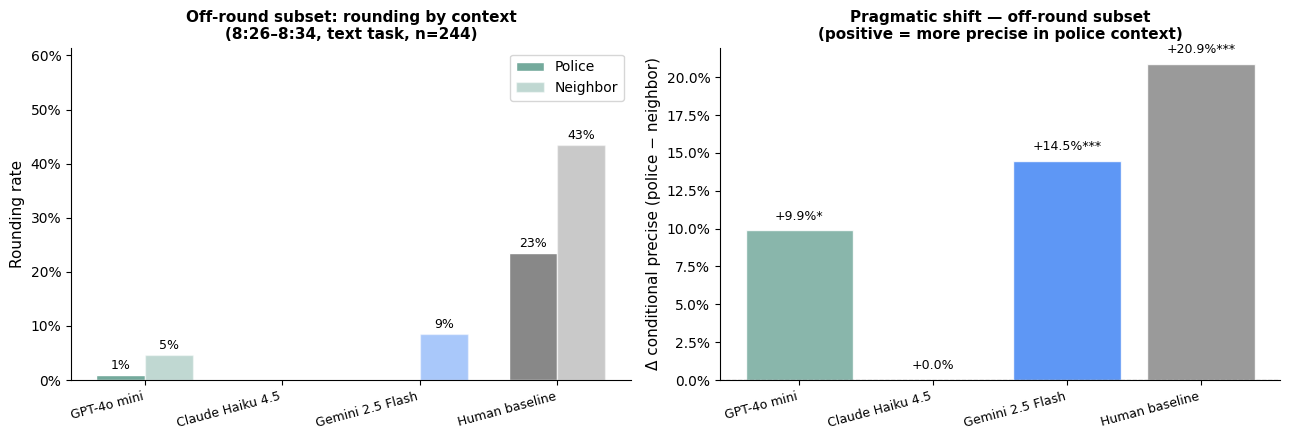

In [16]:
# ── Figure 3: Off-round rounding rates by context ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sources    = or_df["source"].tolist()
x          = np.arange(len(sources))
w          = 0.35
bar_colors = [MODEL_COLORS.get(r["key"], "#888888") for _, r in or_df.iterrows()]

# Left panel: rounding rate police vs neighbor
ax = axes[0]
bars_p = ax.bar(x - w/2, or_df["p_rnd"], w, label="Police",   color=bar_colors, alpha=1.0,  edgecolor="white")
bars_n = ax.bar(x + w/2, or_df["n_rnd"], w, label="Neighbor", color=bar_colors, alpha=0.45, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, max(or_df[["p_rnd","n_rnd"]].max()) * 1.3 + 0.05)
ax.set_ylabel("Rounding rate", fontsize=11)
ax.set_title("Off-round subset: rounding by context\n(8:26–8:34, text task, n=244)", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
for bar in list(bars_p) + list(bars_n):
    h = bar.get_height()
    if h > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.006, f"{h:.0%}",
                ha="center", va="bottom", fontsize=9)

# Right panel: Δ conditional precise (police − neighbor); positive = more precise in police
ax = axes[1]
deltas = or_df["delta_cond"]
bars   = ax.bar(x, deltas, color=bar_colors, edgecolor="white", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(sources, fontsize=9, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Δ conditional precise (police − neighbor)", fontsize=11)
ax.set_title("Pragmatic shift — off-round subset\n(positive = more precise in police context)", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
for bar, val, (_, r) in zip(bars, deltas, or_df.iterrows()):
    label = f"{val:+.1%}"
    if r["pval"] < 0.001: label += "***"
    elif r["pval"] < 0.01: label += "**"
    elif r["pval"] < 0.05: label += "*"
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.005 if val >= 0 else -0.015),
            label, ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("off_round_shift.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ── Per-condition breakdown ───────────────────────────────────────────────────
# Do models fail equally across all clock conditions, or are some harder?
# Compare image accuracy per target_time condition.

cond_rows = []
for key, label in MODELS.items():
    img_col = f"{key}_task1_image"
    df = results.dropna(subset=[img_col]).copy()
    df["correct"] = df.apply(lambda r: time_correct(r[img_col], r["target_time"]), axis=1)
    for tt, grp in df.groupby("target_time"):
        cond_rows.append({"model": label, "target_time": tt, "accuracy": grp["correct"].mean()})

cond_df = pd.pivot_table(
    pd.DataFrame(cond_rows),
    index="target_time", columns="model", values="accuracy"
).round(2)

print("Image task accuracy per clock condition:")
display(cond_df.style.format("{:.0%}").background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1))

Image task accuracy per clock condition:


model,Claude Haiku 4.5,GPT-4o mini,Gemini 2.5 Flash
target_time,,,
8:25,3%,39%,100%
8:26,0%,0%,0%
8:26-8:34,0%,0%,0%
8:27,0%,0%,94%
8:28,0%,0%,8%
8:29,0%,0%,0%
8:30,0%,0%,100%
8:31,0%,0%,0%
8:32,0%,0%,0%


### Key takeaways

**Modality gap confirmed across all 475 rows.** All three models read clock *text descriptions* far more accurately than clock *images*. GPT-4o mini (2.7% → 35.8%) and Claude Haiku (0.2% → 38.1%) essentially fail on images; Gemini 2.5 Flash is substantially better (26.9% image, 54.3% text) but still well below its text performance. The large "other" rate (25–43%) on the text task — misreadings and non-answers — suggests even basic time production is unreliable for a significant fraction of items.

**Pragmatic shift is absent or inverted for all models (full dataset).** Humans produce more precise times in the police context than in the neighbor context (conditional shift: police 65.5% → neighbor 55.6%, Δ = +9.9%). All models fail in different ways:
- **GPT-4o mini:** Δ = −5.3% conditional (inverted direction — *less* precise in police context)
- **Claude Haiku:** Δ = −10.7% conditional (strongly inverted)
- **Gemini 2.5 Flash:** Δ = +4.7% conditional (correct direction but only ~½ of human magnitude)

**Off-round subset reveals further detail.** Restricting to targets where rounding vs. precision is unambiguous (8:26–8:34, excluding canonical 8:25/8:30/8:35), the human shift strengthens: +20.9% conditional, p = 0.0005. Gemini replicates this shift partially (+14.5%, p = 0.0007); GPT-4o mini shows a weak but significant shift (+9.9%, p = 0.039). Claude Haiku produces **zero rounding** in both contexts on off-round targets — it defaults to "other" (wrong/vague times) rather than ever rounding, making it impossible to detect a pragmatic shift at all.

## 8. Open Challenges

**Modality gap — analog clock reading.** All three models read clocks more accurately from text descriptions than from images. GPT-4o mini and Claude Haiku frequently default to "eight o'clock" regardless of what the clock shows. Gemini 2.5 Flash is notably better but still makes errors on off-round times. *Open challenge: better visual grounding for analog clock reading in VLMs.*

**Pragmatic precision calibration.** Models produce digital times at roughly the same rate for police and neighbor contexts. Humans clearly round in casual contexts ("around half past eight") and give exact times in formal ones ("8:28"). Models appear to apply a fixed precision strategy independent of audience. *Open challenge: context-sensitive precision calibration.*

**Task 2 — motive elicitation.** The motive explanations generated by models are fluent and plausible, but they are not yet scored against the human motive annotations. Developing a scoring scheme for pragmatic motive attribution is an open contribution opportunity.

**Open-weight VLMs.** As of mid-2026, benchmarking open-weight VLMs via hosted APIs is non-trivial: most capable models either require dedicated endpoints or have reasoning/thinking modes that interfere with short-response tasks. A local inference setup (e.g. `ollama`, `vllm`) is recommended for open-weight evaluation.

## 9. Extending the Benchmark

**Run the full dataset:**
```bash
python evaluate.py --model gpt-4o-mini --full
```

**Add a new model (OpenAI-compatible):**
```bash
python evaluate.py --model google/gemini-2.5-pro --rows 50  # pilot
python evaluate.py --model google/gemini-2.5-pro --full     # full run
```

**Add a new model (Anthropic):**
```bash
python evaluate.py --model claude-sonnet-4-6 --full
```

Results are merged into `results.csv` automatically — new model columns are added without overwriting existing ones.

**Compute Wasserstein distance** against the human baseline:
```python
from scipy.stats import wasserstein_distance
# human_production_code encodes precision: 0=exact, higher=more imprecise
police   = df[df.context=="police"]["human_production_code"].astype(float)
neighbor = df[df.context=="neighbor"]["human_production_code"].astype(float)
print(wasserstein_distance(police, neighbor))  # human baseline: ~0.27
```